<a href="https://colab.research.google.com/github/eltongaspar/python/blob/Advpl/Aula_02_Aluno_Neuronio_Artificial_Perceptron_ProEducador.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 2 – Estrutura do Neurônio Artificial e Perceptron

## Curso: Deep Learning e Inteligência Artificial Generativa Aplicada

### Capacidades
- Construir redes neurais artificiais.
- Organizar o ambiente de trabalho e as atividades.

### Conhecimentos
- Estrutura do neurônio artificial.
- Perceptron.
- Soma ponderada e viés.
- Funções de ativação.

### Estratégia da aula
Demonstração prática da implementação de um perceptron simples em Python com exercícios guiados, utilizando visualizações para compreender o funcionamento do neurônio artificial, das funções de ativação e da fronteira de decisão.

### Evidência de aprendizagem
Notebook funcional contendo implementação do perceptron, gráficos das funções de ativação, visualização da fronteira de decisão e interpretação dos resultados.

## 1. Contextualização industrial

Nesta aula, vamos estudar o neurônio artificial a partir de um problema simples de classificação industrial.

Imagine que uma equipe de manutenção monitora motores elétricos utilizando dois sinais:

- **Temperatura do enrolamento do motor**;
- **Corrente elétrica consumida pelo motor**.

Com base nesses dois valores, queremos classificar a condição do motor em:

- `0` → operação normal;
- `1` → risco de falha.

Esse exemplo será usado para entender como um neurônio artificial recebe entradas, aplica pesos, soma os valores, adiciona um viés e usa uma função de ativação para gerar uma saída.

## 2. Preparação do ambiente

In [ ]:
# Importe as bibliotecas necessárias para a aula.
# Dica: use numpy, pandas, matplotlib e recursos do scikit-learn.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True
np.random.seed(42)

## 3. Carregamento e visualização do dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Carregue o dataset da aula.
# O arquivo deve estar na mesma pasta do notebook ou disponível no Google Colab.

arquivo = '/content/drive/MyDrive/Classroom/Deep Learning Pró Educador/dataset_aula2_perceptron_motor.csv'

df = pd.read_csv('/content/drive/MyDrive/Classroom/Deep Learning Pró Educador/dataset_aula2_perceptron_motor.csv')  # COMPLETE: informe a variável com o nome do arquivo

df['temperatura_enrolamento_c'].corr(df['corrente_a'])
df.head()

,temperatura_enrolamento_c,corrente_a,risco_falha,situacao
0,65.0,5.12,0,Operação normal
1,61.2,6.35,0,Operação normal
2,65.9,6.61,0,Operação normal
3,71.1,5.23,1,Risco de falha
4,60.6,6.47,0,Operação normal


Dimensões do dataset: (160, 4)


,temperatura_enrolamento_c,corrente_a,risco_falha,situacao
0,65.0,5.12,0,Operação normal
1,61.2,6.35,0,Operação normal
2,65.9,6.61,0,Operação normal
3,71.1,5.23,1,Risco de falha
4,60.6,6.47,0,Operação normal



Distribuição das classes:
risco_falha
1    91
0    69
Name: count, dtype: int64


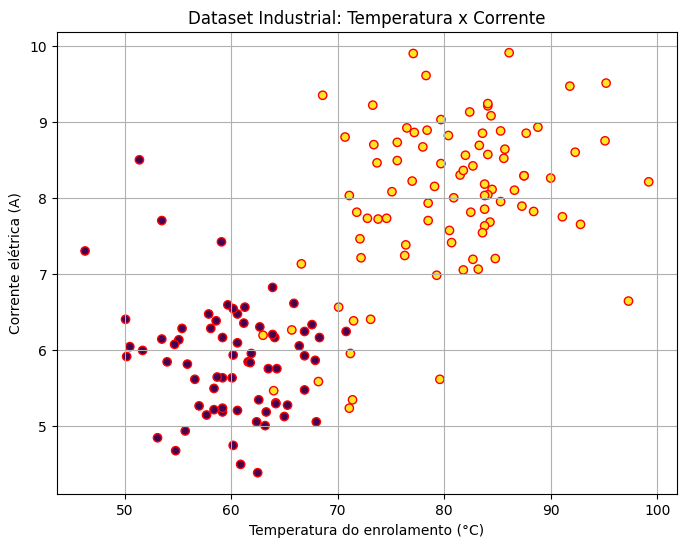

In [ ]:
print('Dimensões do dataset:', df.shape)
display(df.head())

print('\nDistribuição das classes:')
print(df['risco_falha'].value_counts())  # COMPLETE: coluna alvo


plt.figure(figsize=(8, 6))
plt.scatter(
    df['temperatura_enrolamento_c'],  # COMPLETE: temperatura
    df['corrente_a'],  # COMPLETE: corrente
    c=df['risco_falha'], # COMPLETE: classe
    edgecolor='red'
)
plt.title('Dataset Industrial: Temperatura x Corrente')
plt.xlabel('Temperatura do enrolamento (°C)')
plt.ylabel('Corrente elétrica (A)')
plt.show()

## 4. Estrutura do neurônio artificial

Um neurônio artificial é uma representação matemática simplificada inspirada no funcionamento de um neurônio biológico.

No contexto de redes neurais, ele recebe valores de entrada, multiplica cada entrada por um peso, soma esses resultados, adiciona um viés e aplica uma função de ativação.

A estrutura básica é:

$$z = x_1 \cdot w_1 + x_2 \cdot w_2 + \dots + x_n \cdot w_n + b$$

Em que:

- $x$ representa as entradas do modelo;
- $w$ representa os pesos;
- $b$ representa o viés;
- $z$ representa a soma ponderada antes da ativação.

Depois disso, a função de ativação transforma $z$ em uma saída:

$$y = f(z)$$

No nosso exemplo:

- $x_1$ pode representar a temperatura do motor;
- $x_2$ pode representar a corrente elétrica;
- a saída pode indicar operação normal ou risco de falha.

In [ ]:
padrao = StandardScaler()
temp = padrao.fit_transform(df[['temperatura_enrolamento_c']])
temp.mean()

np.float64(-2.6645352591003756e-16)

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 1. Instancia o normalizador
normalizador = MinMaxScaler()

# 2. Aplica a normalização (lembrando de usar dois colchetes [[ ]])
df['temperatura_normalizada'] = normalizador.fit_transform(df[['temperatura_enrolamento_c']])

df.describe()

,temperatura_enrolamento_c,corrente_a,risco_falha,temperatura_normalizada
count,160.000000,160.000000,160.000000,160.000000
mean,71.590625,7.067063,0.568750,0.478084
std,12.011487,1.395777,0.496806,0.227060
min,46.300000,4.380000,0.000000,0.000000
25%,61.275000,5.917500,0.000000,0.283081
50%,71.300000,7.095000,1.000000,0.472590
75%,82.425000,8.267500,1.000000,0.682892
max,99.200000,9.910000,1.000000,1.000000


In [ ]:
# Complete o cálculo manual do neurônio artificial.


x1 = 0.8  # temperatura normalizada
x2 = 0.6  # corrente normalizada

w1 = 0.7  # peso da temperatura
w2 = 0.4  # peso da corrente

b = -0.5   # viés

z = (x1 * w1) + (x2 * w2) + b   # COMPLETE: soma ponderada

print(f'Soma ponderada z = {z:.3f}')

saida = 1 if z > 0 else 0  # COMPLETE: aplique a regra degrau: 1 se z >= 0; caso contrário, 0
print(f'Saída do neurônio = {saida}')

Soma ponderada z = 0.300
Saída do neurônio = 1


## 5. Funções de ativação

A função de ativação define como o neurônio transforma a soma ponderada em uma saída.

Ela é importante porque permite que redes neurais aprendam relações mais complexas. Sem funções de ativação, uma rede com várias camadas se comportaria, na prática, como uma combinação linear, limitando sua capacidade de resolver problemas mais difíceis.

Nesta aula, vamos visualizar separadamente cinco funções importantes:

1. Função degrau;
2. Sigmoid;
3. Tanh;
4. ReLU;
5. Softmax.

### 5.1 Função Degrau

A função degrau gera uma saída binária. Ela será usada no perceptron clássico.

Complete a implementação abaixo.

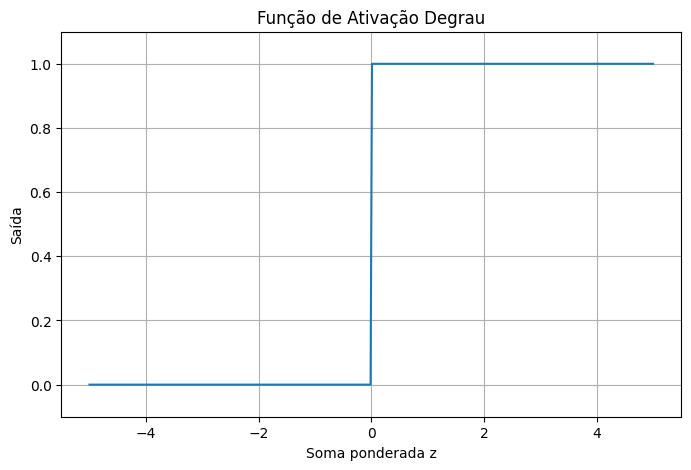

In [ ]:
def ativacao_degrau(z):
    return np.where(z>=0, 1, 0)  # COMPLETE: z >= 0, saída 1, saída 0

z = np.linspace(-5, 5, 400)

y_degrau = ativacao_degrau(z)

plt.figure()
plt.plot(z, y_degrau)
plt.title('Função de Ativação Degrau')
plt.xlabel('Soma ponderada z')
plt.ylabel('Saída')
plt.ylim(-0.1, 1.1)
plt.show()

### 5.2 Função Sigmoid

A função sigmoid gera uma saída entre 0 e 1. Ela pode ser interpretada como probabilidade em problemas binários.

Complete a implementação.

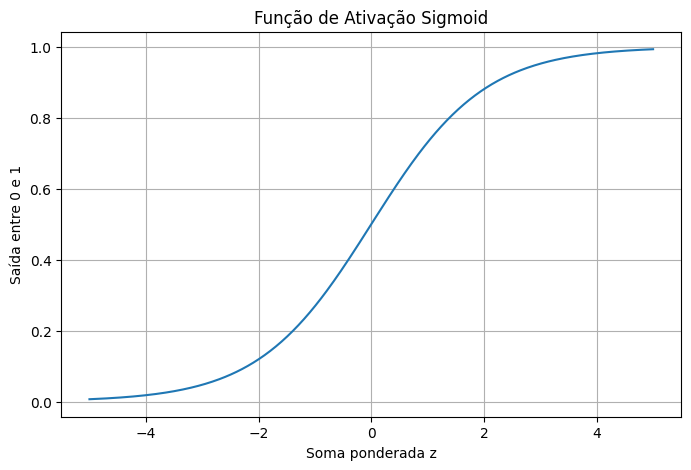

In [ ]:
def sigmoid(z):
    return 1/(1+ np.exp(-z))  # COMPLETE: fórmula 1 / (1 + exp(-z))

y_sigmoid = sigmoid(z)

plt.figure()
plt.plot(z, y_sigmoid)
plt.title('Função de Ativação Sigmoid')
plt.xlabel('Soma ponderada z')
plt.ylabel('Saída entre 0 e 1')
plt.show()

### 5.3 Função Tanh

A função Tanh gera uma saída entre -1 e 1.

Complete a implementação.

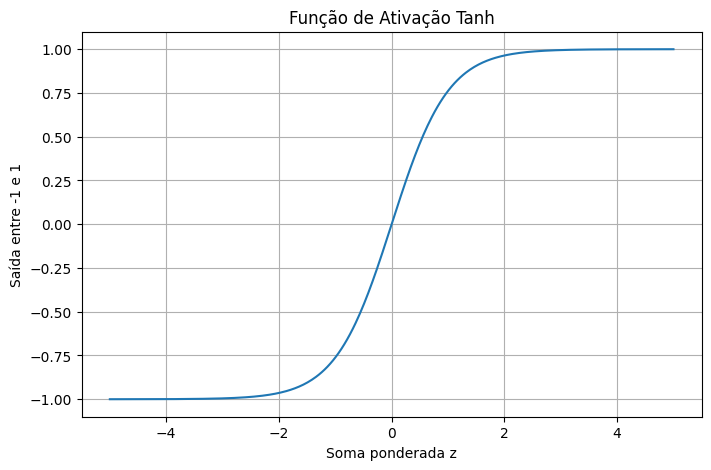

In [ ]:
def tanh(z):
    return np.tanh(z)  # COMPLETE: use np.tanh(z)

y_tanh = tanh(z)

plt.figure()
plt.plot(z, y_tanh)
plt.title('Função de Ativação Tanh')
plt.xlabel('Soma ponderada z')
plt.ylabel('Saída entre -1 e 1')
plt.show()

### 5.4 Função ReLU

A função ReLU mantém valores positivos e transforma valores negativos em zero.

Complete a implementação.

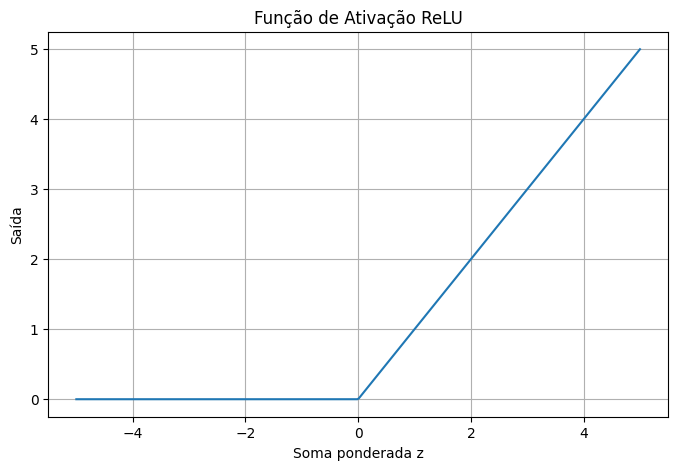

In [ ]:
def relu(z):
    return np.maximum(0,z)  # COMPLETE: use np.maximum(0, z)

y_relu = relu(z)

plt.figure()
plt.plot(z, y_relu)
plt.title('Função de Ativação ReLU')
plt.xlabel('Soma ponderada z')
plt.ylabel('Saída')
plt.show()

### 5.5 Função Softmax

A função Softmax transforma valores em probabilidades para classificação multiclasse.

Complete a implementação.

Normal: 26.87%
Atenção: 59.79%
Risco: 13.34%


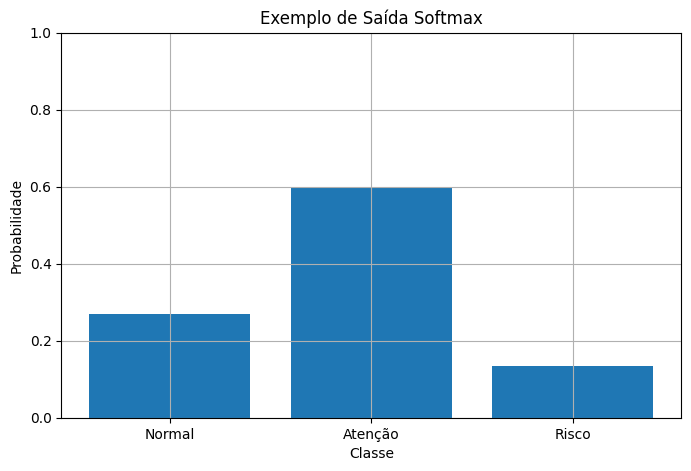

In [ ]:
def softmax(vetor):
    exp_valores = np.exp(vetor - np.max(vetor))
    return exp_valores / np.sum(exp_valores)  # COMPLETE: divida exp_valores pela soma de exp_valores

classes = ['Normal', 'Atenção', 'Risco']
logits = np.array([1.2, 2.0, 0.5])
probabilidades = softmax(logits)

for classe, prob in zip(classes, probabilidades):
    print(f'{classe}: {prob:.2%}')

plt.figure()
plt.bar(classes, probabilidades)
plt.title('Exemplo de Saída Softmax')
plt.xlabel('Classe')
plt.ylabel('Probabilidade')
plt.ylim(0, 1)
plt.show()

### 5.6 Comparação entre funções de ativação

Após implementar as funções, gere o gráfico comparativo.

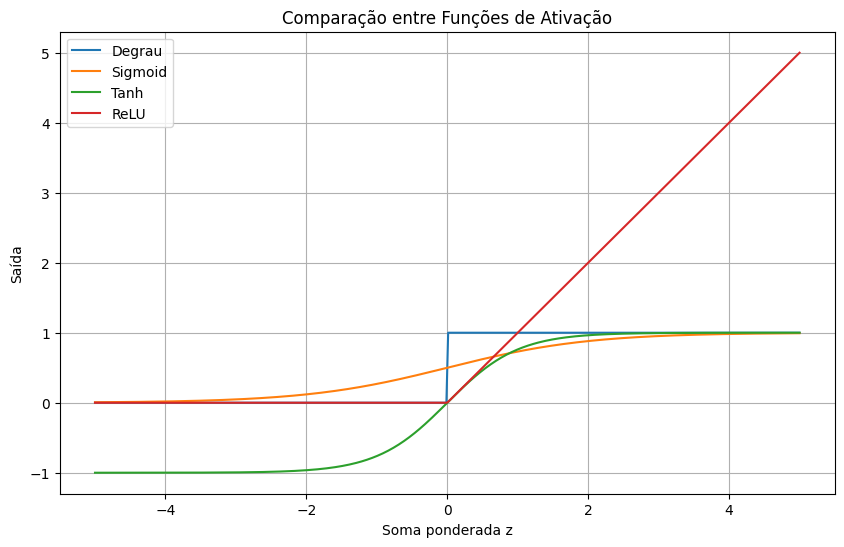

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(z, y_degrau, label='Degrau')
plt.plot(z, y_sigmoid, label='Sigmoid')
plt.plot(z, y_tanh, label='Tanh')
plt.plot(z, y_relu, label='ReLU')
plt.title('Comparação entre Funções de Ativação')
plt.xlabel('Soma ponderada z')
plt.ylabel('Saída')
plt.legend()
plt.show()

## 6. O que é o Perceptron?

O perceptron é um dos modelos mais simples de neurônio artificial utilizado para classificação binária.

Ele funciona em quatro etapas principais:

1. **Recebe as entradas**: no nosso caso, temperatura e corrente do motor;
2. **Multiplica cada entrada por um peso**: cada peso indica a importância daquela variável;
3. **Soma os resultados e adiciona o viés**: essa etapa gera a soma ponderada;
4. **Aplica a função de ativação**: geralmente a função degrau, gerando a classe 0 ou 1.

A regra geral é:

$$z = x_1w_1 + x_2w_2 + b$$

$$\hat{y} = \begin{cases}
1, & \text{se } z \geq 0 \\
0, & \text{se } z < 0
\end{cases}$$

Durante o treinamento, quando o perceptron erra uma previsão, ele ajusta os pesos e o viés.

A regra de atualização é:

$$w = w + \eta \cdot \text{erro} \cdot x$$

$$b = b + \eta \cdot \text{erro}$$

Em que:

- $\eta$ é a taxa de aprendizado;
- $\text{erro} = y - \hat{y}$;
- $x$ é o valor de entrada;
- $y$ é o valor real;
- $\hat{y}$ é a previsão do modelo.

O perceptron é indicado para problemas linearmente separáveis, ou seja, problemas em que uma reta consegue separar as classes.

## 7. Preparação dos dados para treinamento

In [ ]:
X = df[['temperatura_enrolamento_c', 'corrente_a']].values  # COMPLETE: nomes das colunas de entrada
y = df['risco_falha'].values           # COMPLETE: coluna alvo

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_treino_norm = scaler.fit_transform(X_treino)
X_teste_norm = scaler.transform(X_teste)

print('Formato do conjunto de treino:', X_treino_norm.shape)
print('Formato do conjunto de teste:', X_teste_norm.shape)

Formato do conjunto de treino: (120, 2)
Formato do conjunto de teste: (40, 2)


In [ ]:
class PerceptronSimples:
    def __init__(self, taxa_aprendizado=0.1, epocas=300):
        self.taxa_aprendizado = taxa_aprendizado
        self.epocas = epocas
        self.pesos = None
        self.vies = 0
        self.erros_por_epoca = []

    def ativacao(self, z):
        return 1 if z >=0 else 0  # COMPLETE: retorne 1 se z >= 0, senão 0

    def treinar(self, X, y):
        n_amostras, n_caracteristicas = X.shape
        self.pesos = np.zeros(n_caracteristicas)
        self.vies = 0

        for epoca in range(self.epocas):
            erros = 0

            for xi, alvo in zip(X, y):
                z = np.dot(xi, self.pesos) + self.vies  # COMPLETE: np.dot(xi, self.pesos) + self.vies
                previsao = self.ativacao(z)
                erro = alvo - previsao  # COMPLETE: alvo - previsao

                if erro != 0:
                    self.pesos += self.taxa_aprendizado * erro * xi  # COMPLETE: taxa * erro * xi
                    self.vies += self.taxa_aprendizado * erro   # COMPLETE: taxa * erro
                    erros += 1

            self.erros_por_epoca.append(erros)
            print(f'Época {epoca+1:02d} | Erros: {erros}')

    def prever(self, X):
        saidas = []
        for xi in X:
            z = np.dot(xi, self.pesos) + self.vies  # COMPLETE: soma ponderada
            saidas.append(self.ativacao(z))
        return np.array(saidas)

In [ ]:
perceptron = PerceptronSimples(taxa_aprendizado=0.1, epocas=300)
perceptron.treinar(X_treino_norm, y_treino)

print('\nPesos aprendidos:', perceptron.pesos)
print('Viés aprendido:', perceptron.vies)

Época 01 | Erros: 11
Época 02 | Erros: 11
Época 03 | Erros: 10
Época 04 | Erros: 12
Época 05 | Erros: 6
Época 06 | Erros: 10
Época 07 | Erros: 12
Época 08 | Erros: 6
Época 09 | Erros: 10
Época 10 | Erros: 12
Época 11 | Erros: 8
Época 12 | Erros: 10
Época 13 | Erros: 8
Época 14 | Erros: 10
Época 15 | Erros: 8
Época 16 | Erros: 9
Época 17 | Erros: 11
Época 18 | Erros: 8
Época 19 | Erros: 10
Época 20 | Erros: 8
Época 21 | Erros: 8
Época 22 | Erros: 8
Época 23 | Erros: 12
Época 24 | Erros: 10
Época 25 | Erros: 6
Época 26 | Erros: 10
Época 27 | Erros: 12
Época 28 | Erros: 6
Época 29 | Erros: 10
Época 30 | Erros: 8
Época 31 | Erros: 10
Época 32 | Erros: 12
Época 33 | Erros: 6
Época 34 | Erros: 12
Época 35 | Erros: 8
Época 36 | Erros: 12
Época 37 | Erros: 10
Época 38 | Erros: 6
Época 39 | Erros: 10
Época 40 | Erros: 8
Época 41 | Erros: 10
Época 42 | Erros: 10
Época 43 | Erros: 12
Época 44 | Erros: 10
Época 45 | Erros: 6
Época 46 | Erros: 10
Época 47 | Erros: 8
Época 48 | Erros: 10
Época 49 | 

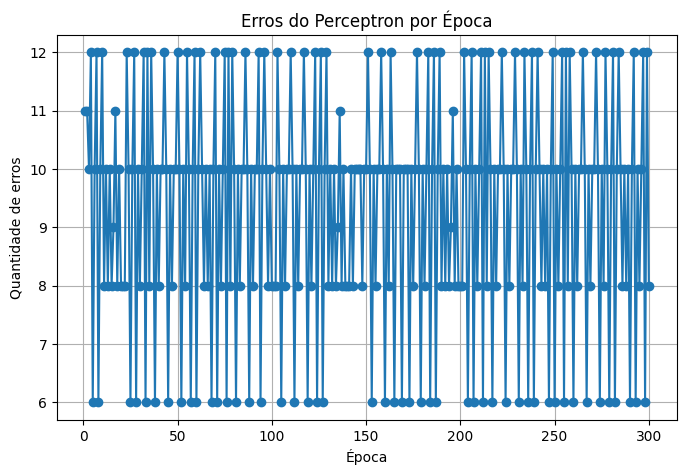

Acurácia: 0.85

Matriz de confusão:
[[12  5]
 [ 1 22]]

Relatório de classificação:
              precision    recall  f1-score   support

           0       0.92      0.71      0.80        17
           1       0.81      0.96      0.88        23

    accuracy                           0.85        40
   macro avg       0.87      0.83      0.84        40
weighted avg       0.86      0.85      0.85        40



array([[12,  5],
       [ 1, 22]])

In [ ]:
plt.figure()
plt.plot(range(1, len(perceptron.erros_por_epoca)+1), perceptron.erros_por_epoca, marker='o')
plt.title('Erros do Perceptron por Época')
plt.xlabel('Época')
plt.ylabel('Quantidade de erros')
plt.show()

y_pred = perceptron.prever(X_teste_norm)

print('Acurácia:', accuracy_score(y_teste, y_pred))
print('\nMatriz de confusão:')
print(confusion_matrix(y_teste, y_pred))
print('\nRelatório de classificação:')
print(classification_report(y_teste, y_pred))
confusion_matrix(y_teste, y_pred)

In [ ]:
cm = confusion_matrix(y_teste, y_pred)
cm_df = pd.DataFrame(cm, index=['Real 0', 'Real 1'], columns=['Previsto 0', 'Previsto 1'])
display(cm_df)

,Previsto 0,Previsto 1
Real 0,12,5
Real 1,1,22


## 8. Fronteira de decisão

A fronteira de decisão é a linha que separa as regiões onde o modelo prevê uma classe ou outra.

No caso do perceptron com duas entradas, a decisão é baseada em:

$$z = x_1w_1 + x_2w_2 + b$$

A fronteira ocorre quando:

$$z = 0$$

Portanto:

$$x_1w_1 + x_2w_2 + b = 0$$

Como estamos trabalhando com duas variáveis, a fronteira de decisão aparece como uma reta no gráfico.

Isolando $x_2$ (que fará o papel do eixo $Y$ no gráfico), temos a equação explícita da reta:

$$x_2 = -\left(\frac{w_1}{w_2}\right)x_1 - \frac{b}{w_2}$$

Onde:
- $-\frac{w_1}{w_2}$ é o coeficiente angular (inclinação da reta);
- $-\frac{b}{w_2}$ é o coeficiente linear (onde a reta corta o eixo vertical).

No exemplo industrial:

- um lado da reta representa motores classificados como operação normal;
- o outro lado representa motores classificados como risco de falha.

Essa visualização ajuda o aluno a perceber que o perceptron está aprendendo uma separação linear entre as classes.

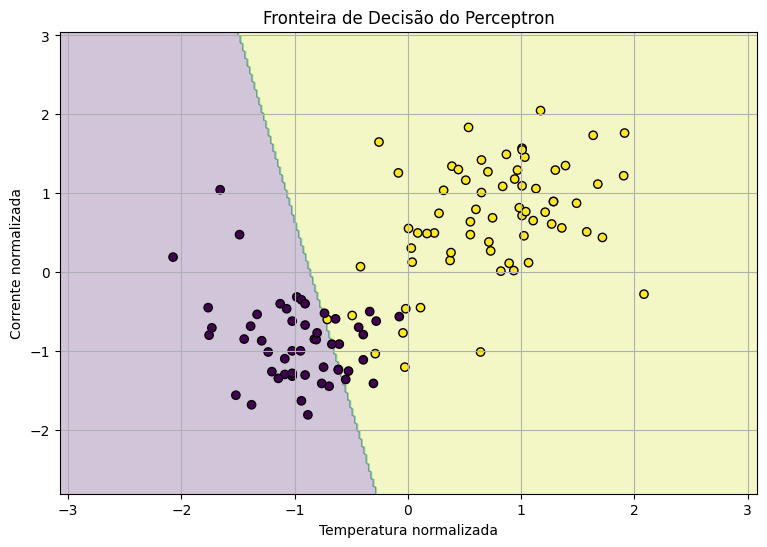

In [ ]:
def plotar_fronteira_decisao(X_norm, y, modelo):
    x_min, x_max = X_norm[:, 0].min() - 1, X_norm[:, 0].max() + 1
    y_min, y_max = X_norm[:, 1].min() - 1, X_norm[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )

    grade = np.c_[xx.ravel(), yy.ravel()]
    predicoes = modelo.prever(grade).reshape(xx.shape)  # COMPLETE

    plt.figure(figsize=(9, 6))
    plt.contourf(xx, yy, predicoes, alpha=0.25)
    plt.scatter(X_norm[:, 0], X_norm[:, 1], c=y, edgecolor='k')
    plt.title('Fronteira de Decisão do Perceptron')
    plt.xlabel('Temperatura normalizada')
    plt.ylabel('Corrente normalizada')
    plt.show()

plotar_fronteira_decisao(X_treino_norm, y_treino, perceptron)

## 9. Atividade de fechamento

Responda no Google Classroom ou em uma célula Markdown no final deste notebook:

1. O que representam os pesos em um neurônio artificial?

Os pesos em um neurônio artificial são parâmetros numéricos associados a cada entrada, utilizados para ponderar sua contribuição no cálculo da saída.
Eles definem a influência relativa de cada variável de entrada no modelo.
O neurônio realiza uma combinação linear entre entradas e pesos, geralmente somada a um viés.
Pesos positivos reforçam a ativação do neurônio, enquanto pesos negativos a inibem.
Durante o treinamento, os pesos são ajustados por algoritmos de otimização (como gradiente descendente).
Esse ajuste minimiza o erro entre a saída prevista e a saída desejada.
Assim, os pesos codificam o conhecimento aprendido pelo modelo a partir dos dados.

2. Qual é a função do viés?

O viés é um parâmetro adicional somado à combinação das entradas ponderadas, permitindo ajustar o nível de ativação do neurônio independentemente dos valores de entrada.
Ele atua como um deslocamento da função de ativação.
Sua principal função é evitar que o modelo seja limitado a passar pela origem (valor zero).
Isso aumenta a flexibilidade do neurônio na representação de padrões.
O viés também é ajustado durante o treinamento, assim como os pesos.
Dessa forma, contribui para melhorar a capacidade de aprendizado do modelo.

3. Por que a função de ativação é necessária?

A função de ativação é necessária para introduzir não linearidade no neurônio artificial.
Sem ela, o modelo se comportaria como uma simples combinação linear, limitando sua capacidade de representar padrões complexos.
Ela transforma a soma ponderada das entradas em um valor de saída adequado.
Permite que a rede neural aprenda relações não lineares entre os dados.
Também ajuda a definir quando o neurônio deve ser ativado ou não.
Funções comuns incluem ReLU, sigmoide e tangente hiperbólica.
Assim, a função de ativação é essencial para o poder de aprendizado das redes neurais.

4. Por que o perceptron gera uma fronteira de decisão linear?

O perceptron gera uma fronteira de decisão linear porque sua saída é baseada em uma combinação linear das entradas.
Ele calcula a soma ponderada (entradas × pesos) mais o viés.
Essa combinação define uma função linear no espaço de entrada.
A função de ativação (como o degrau) apenas separa os dados com base em um limite.
Como resultado, a separação entre classes ocorre por uma reta (2D), plano (3D) ou hiperplano (múltiplas dimensões).
Assim, o perceptron só consegue resolver problemas linearmente separáveis.

5. Em quais situações industriais o perceptron pode ser limitado?

O perceptron é limitado em situações industriais que envolvem problemas não linearmente separáveis.
Ele não consegue modelar relações complexas entre variáveis, comuns em cenários reais.
Tarefas como reconhecimento de imagem, detecção de falhas complexas e previsão com múltiplos fatores não lineares excedem sua capacidade.
Também apresenta limitação em dados com alta dimensionalidade e padrões não lineares.
Além disso, não se adapta bem a problemas com múltiplas classes sem modificações.
Em aplicações industriais modernas, redes neurais mais profundas são preferidas por sua maior capacidade de generalização.

### Entrega

- Notebook preenchido;
- Gráficos das funções de ativação;
- Implementação do perceptron;
- Visualização da fronteira de decisão;
- Respostas técnicas registradas.